In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import sys
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(str(Path('..').resolve()))

from src.utils.paths import PROCESSED_DIR, RESULTS_DIR, setup_plotting, ensure_dirs
from src.data.preprocessing import prepare_lstm_data
from src.models.rnn import AttentionModel
from src.training.rnn import train_attention_with_cv

setup_plotting()
ensure_dirs()

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## Load Datasets

In [2]:
dataset_A = pd.read_csv(PROCESSED_DIR / 'dataset_A_full.csv')
dataset_B = pd.read_csv(PROCESSED_DIR / 'dataset_B_metabolomics.csv')
dataset_C = pd.read_csv(PROCESSED_DIR / 'dataset_C_transcriptomics.csv')

print("Dataset shapes:")
print(f"  A (Full): {dataset_A.shape}")
print(f"  B (Metabolomics): {dataset_B.shape}")
print(f"  C (Transcriptomics): {dataset_C.shape}")

Dataset shapes:
  A (Full): (33, 1176)
  B (Metabolomics): (79, 206)
  C (Transcriptomics): (31, 212)


## Prepare Temporal Data for sequential models

In [3]:
X_A, y_A, features_A = prepare_lstm_data(dataset_A, "Dataset A")
X_B, y_B, features_B = prepare_lstm_data(dataset_B, "Dataset B")
X_C, y_C, features_C = prepare_lstm_data(dataset_C, "Dataset C")


Dataset A:
  Samples: 33
  Common features: 582
  Temporal shape: (33, 2, 582) (samples, timesteps, features)

Dataset B:
  Samples: 79
  Common features: 97
  Temporal shape: (79, 2, 97) (samples, timesteps, features)

Dataset C:
  Samples: 31
  Common features: 100
  Temporal shape: (31, 2, 100) (samples, timesteps, features)


## Train


In [4]:
print("="*60)
print("DATASET A: Full")
print("="*60)
results_A = train_attention_with_cv(
    model_class=AttentionModel,
    X=X_A,
    y=y_A,
    feature_names=features_A,
    n_splits=5,
    hidden_dim=64,
    dropout=0.3,
    lr=0.001,
    epochs=100,
    batch_size=8,
    random_state=42
)

print("\n" + "="*60)
print("DATASET B: Metabolomics")
print("="*60)
results_B = train_attention_with_cv(
    model_class=AttentionModel,
    X=X_B,
    y=y_B,
    feature_names=features_B,
    n_splits=5,
    hidden_dim=64,
    dropout=0.3,
    lr=0.001,
    epochs=100,
    batch_size=8,
    random_state=42
)

print("\n" + "="*60)
print("DATASET C: Transcriptomics")
print("="*60)
results_C = train_attention_with_cv(
    model_class=AttentionModel,
    X=X_C,
    y=y_C,
    feature_names=features_C,
    n_splits=5,
    hidden_dim=64,
    dropout=0.3,
    lr=0.001,
    epochs=100,
    batch_size=8,
    random_state=42
)


DATASET A: Full
Using device: cuda
Training 5-fold CV (Imputation & Scaling inside folds)...


  Fold 1: R²=-14.540, RMSE=11.482, MAE=5.924


  Fold 2: R²=0.052, RMSE=5.305, MAE=4.380


  Fold 3: R²=-1.564, RMSE=6.912, MAE=5.487


  Fold 4: R²=-0.620, RMSE=5.633, MAE=4.397


...

  Fold 1: R²=0.360, RMSE=3.825, MAE=2.490


  Fold 2: R²=0.746, RMSE=1.981, MAE=1.698


  Fold 3: R²=0.502, RMSE=2.690, MAE=1.813


  Fold 4: R²=-0.963, RMSE=2.979, MAE=2.199


  Fold 5: R²=0.265, RMSE=4.836, MAE=3.681

R² = 0.182 ± 0.665


## Results Summary

In [5]:
summary = pd.DataFrame([
    {'Dataset': 'A (Full)', 'N': len(X_A), 'Features': X_A.shape[2],
     'R²': f"{results_A['mean_r2']:.3f} ± {results_A['std_r2']:.3f}",
     'RMSE': f"{results_A['mean_rmse']:.3f} ± {results_A['std_rmse']:.3f}",
     'MAE': f"{results_A['mean_mae']:.3f} ± {results_A['std_mae']:.3f}"},
    {'Dataset': 'B (Metabolomics)', 'N': len(X_B), 'Features': X_B.shape[2],
     'R²': f"{results_B['mean_r2']:.3f} ± {results_B['std_r2']:.3f}",
     'RMSE': f"{results_B['mean_rmse']:.3f} ± {results_B['std_rmse']:.3f}",
     'MAE': f"{results_B['mean_mae']:.3f} ± {results_B['std_mae']:.3f}"},
    {'Dataset': 'C (Transcriptomics)', 'N': len(X_C), 'Features': X_C.shape[2],
     'R²': f"{results_C['mean_r2']:.3f} ± {results_C['std_r2']:.3f}",
     'RMSE': f"{results_C['mean_rmse']:.3f} ± {results_C['std_rmse']:.3f}",
     'MAE': f"{results_C['mean_mae']:.3f} ± {results_C['std_mae']:.3f}"}
])

print("\nRESULTS SUMMARY:")
print(summary.to_string(index=False))
summary.to_csv(RESULTS_DIR / 'attention_summary.csv', index=False)


RESULTS SUMMARY:
            Dataset  N  Features             R²          RMSE           MAE
           A (Full) 33       582 -3.672 ± 6.117 6.474 ± 3.129 4.571 ± 1.262
   B (Metabolomics) 79        97 -0.223 ± 0.406 4.275 ± 0.936 3.453 ± 0.593
C (Transcriptomics) 31       100  0.182 ± 0.665 3.262 ± 1.100 2.376 ± 0.794


## Visualizations

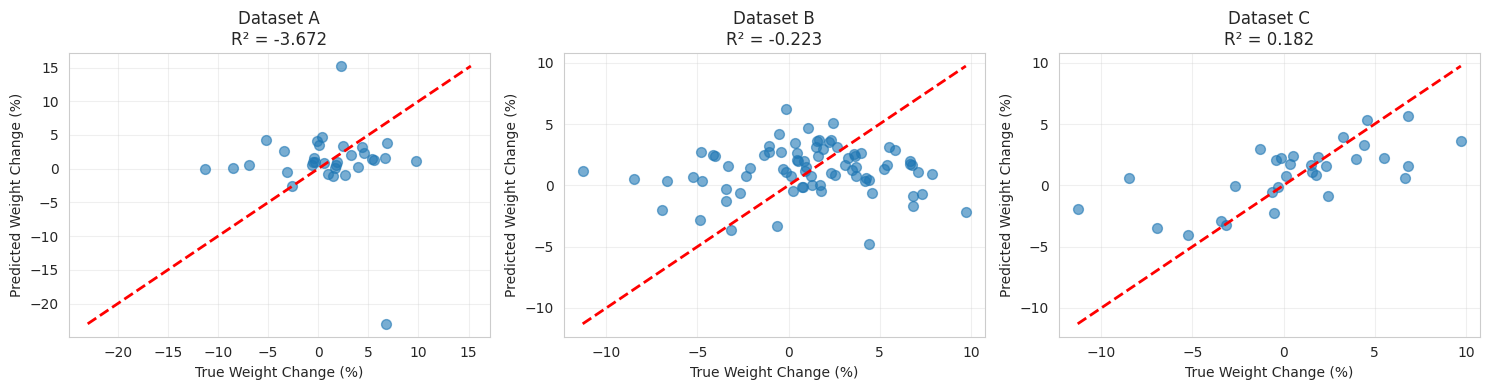

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, results, name in zip(axes, [results_A, results_B, results_C], ['Dataset A', 'Dataset B', 'Dataset C']):
    ax.scatter(results['y_true'], results['y_pred'], alpha=0.6, s=50)
    min_val = min(results['y_true'].min(), results['y_pred'].min())
    max_val = max(results['y_true'].max(), results['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_xlabel('True Weight Change (%)')
    ax.set_ylabel('Predicted Weight Change (%)')
    ax.set_title(f'{name}\nR² = {results["mean_r2"]:.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'attention_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## Attention Weight Analysis


Average Attention Weights (Dataset B):
Shape: (2, 2)

Mean Attention Matrix:
        WL      WM
WL:  0.443  0.557
WM:  0.365  0.635

Interpretation:
  - When predicting from WL: attends 44.3% to WL, 55.7% to WM
  - When predicting from WM: attends 36.5% to WL, 63.5% to WM


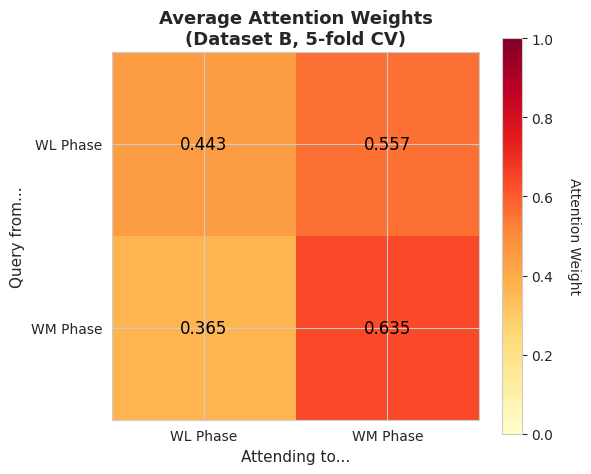


Heatmap saved to /home/bendavison/PycharmProjects/msc_dissertation/results/attention_weights_heatmap.png


In [7]:
# Analyze attention weights from Dataset B
if 'attention_weights' in results_B and len(results_B['attention_weights']) > 0:
    # Average attention weights across all folds
    all_weights = []
    for fold_weights in results_B['attention_weights']:
        # Average over batch dimension
        avg_fold = fold_weights.mean(axis=0)
        all_weights.append(avg_fold)
    
    # Average across folds: [seq_len=2, seq_len=2]
    mean_attention = np.array(all_weights).mean(axis=0)
    std_attention = np.array(all_weights).std(axis=0)
    
    print("\nAverage Attention Weights (Dataset B):")
    print("Shape:", mean_attention.shape)
    print("\nMean Attention Matrix:")
    print("        WL      WM")
    print(f"WL:  {mean_attention[0,0]:.3f}  {mean_attention[0,1]:.3f}")
    print(f"WM:  {mean_attention[1,0]:.3f}  {mean_attention[1,1]:.3f}")
    
    print("\nInterpretation:")
    print(f"  - When predicting from WL: attends {mean_attention[0,0]*100:.1f}% to WL, {mean_attention[0,1]*100:.1f}% to WM")
    print(f"  - When predicting from WM: attends {mean_attention[1,0]*100:.1f}% to WL, {mean_attention[1,1]*100:.1f}% to WM")
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(6, 5))
    
    im = ax.imshow(mean_attention, cmap='YlOrRd', vmin=0, vmax=1)
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['WL Phase', 'WM Phase'])
    ax.set_yticklabels(['WL Phase', 'WM Phase'])
    ax.set_xlabel('Attending to...', fontsize=11)
    ax.set_ylabel('Query from...', fontsize=11)
    
    # Add values
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, f'{mean_attention[i, j]:.3f}',
                          ha='center', va='center', color='black', fontsize=12)
    
    ax.set_title('Average Attention Weights\n(Dataset B, 5-fold CV)', fontsize=13, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Attention Weight', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'attention_weights_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nHeatmap saved to {RESULTS_DIR / 'attention_weights_heatmap.png'}")
    
else:
    print("No attention weights available for visualization.")

## Save Results

In [8]:
attention_results = {'dataset_A': results_A, 'dataset_B': results_B, 'dataset_C': results_C, 'summary': summary}
with open(RESULTS_DIR / 'attention_results.pkl', 'wb') as f:
    pickle.dump(attention_results, f)
print("Results saved to", RESULTS_DIR)

# Save attention weights separately for easier access
attention_weights_data = {}
attention_weights_data["A"] = results_A['attention_weights']
attention_weights_data["B"] = results_B['attention_weights']
attention_weights_data["C"] = results_C['attention_weights']


with open(RESULTS_DIR / 'attention_weights.pkl', 'wb') as f:
    pickle.dump(attention_weights_data, f)

print(f"Attention weights saved to {RESULTS_DIR / 'attention_weights.pkl'}")

Results saved to /home/bendavison/PycharmProjects/msc_dissertation/results
Attention weights saved to /home/bendavison/PycharmProjects/msc_dissertation/results/attention_weights.pkl
